# Predicting Housing Prices With Gradient Boosted Decision Trees

This project walks through the analysis and prediction of housing prices using the Ames Housing dataset. We will cover data preprocessing, feature engineering, and building a predictive model using a gradient boosting regressor. Let's dive in!

## Setting Up the Environment

We begin by configuring the plotting backend, importing necessary libraries, and setting display options for pandas to handle large datasets effectively. These steps ensure that plots are rendered in high quality and that all columns of the dataset are visible without truncation, making it easier to analyze data comprehensively.

In [1]:
%config InlineBackend.figure_format = 'retina'

In [2]:
from matplotlib.gridspec import GridSpec
from matplotlib.pyplot import *
import pandas as pd
import numpy as np

rc('font', size=8)

pd.set_option('display.max_columns', 500)

## Loading and Cleaning the Data

Next, we load the dataset and perform initial cleaning. Outliers, such as houses with disproportionately large living areas but low sale prices, are removed. This helps improve the reliability of our analysis and ensures the model focuses on typical data patterns.

In [3]:
df = pd.read_csv('data/train.csv')

df = df[~((df['SalePrice'] < 300000) & (df['GrLivArea'] > 4000))].reset_index(drop=True)

## Exploratory Data Analysis

We begin by visualizing missing data in the dataset. Missing data can provide insight into the quality of the dataset and highlight features that may require imputation or special handling.

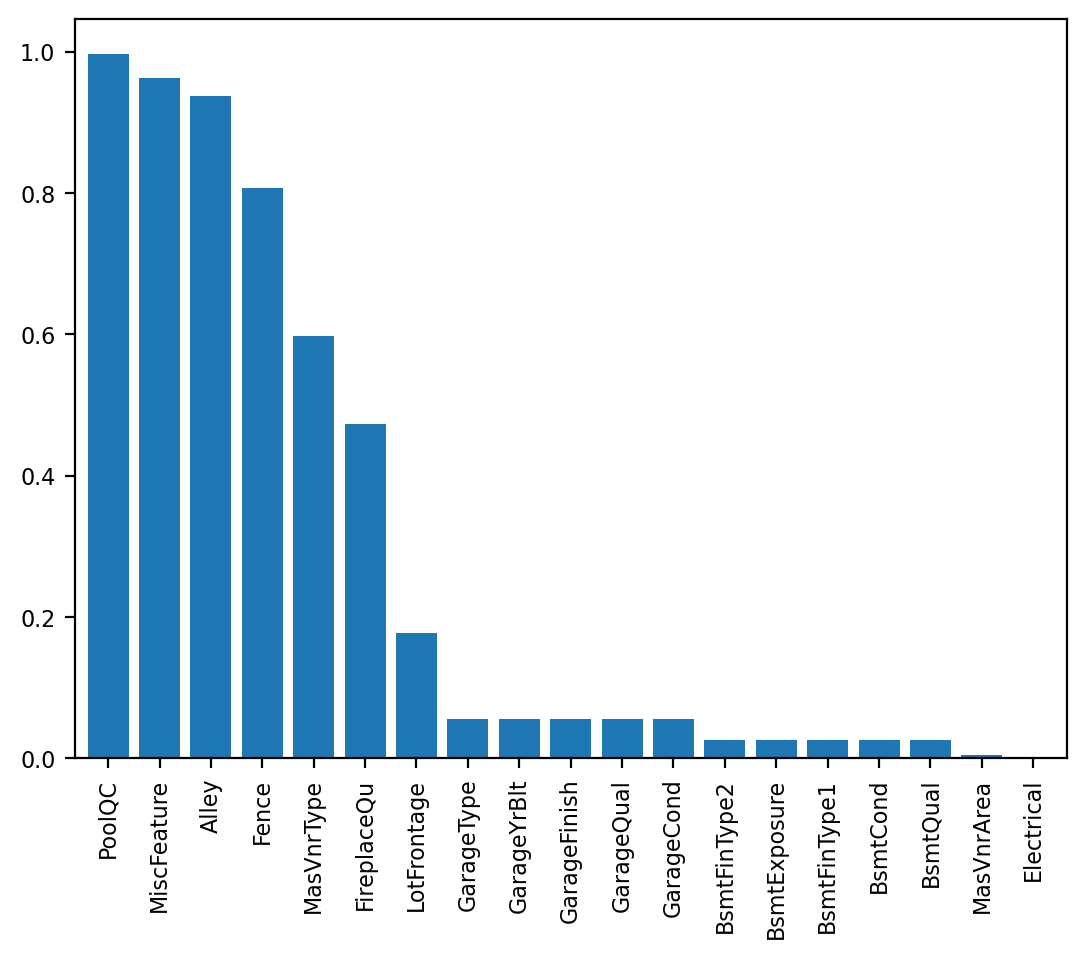

In [4]:
(df.isnull().sum()[lambda x: x > 0] / len(df)).sort_values(ascending=False).plot.bar(width=0.8);

Further, we explore relationships between important features and the target variable, ```SalePrice```. Scatter plots, such as the one between ```GrLivArea``` and ```SalePrice```, help identify linear or non-linear trends. Grouped bar charts reveal median ```SalePrice``` trends across categories like ```Neighborhood``` and ```OverallQual```, providing a deeper understanding of the data.

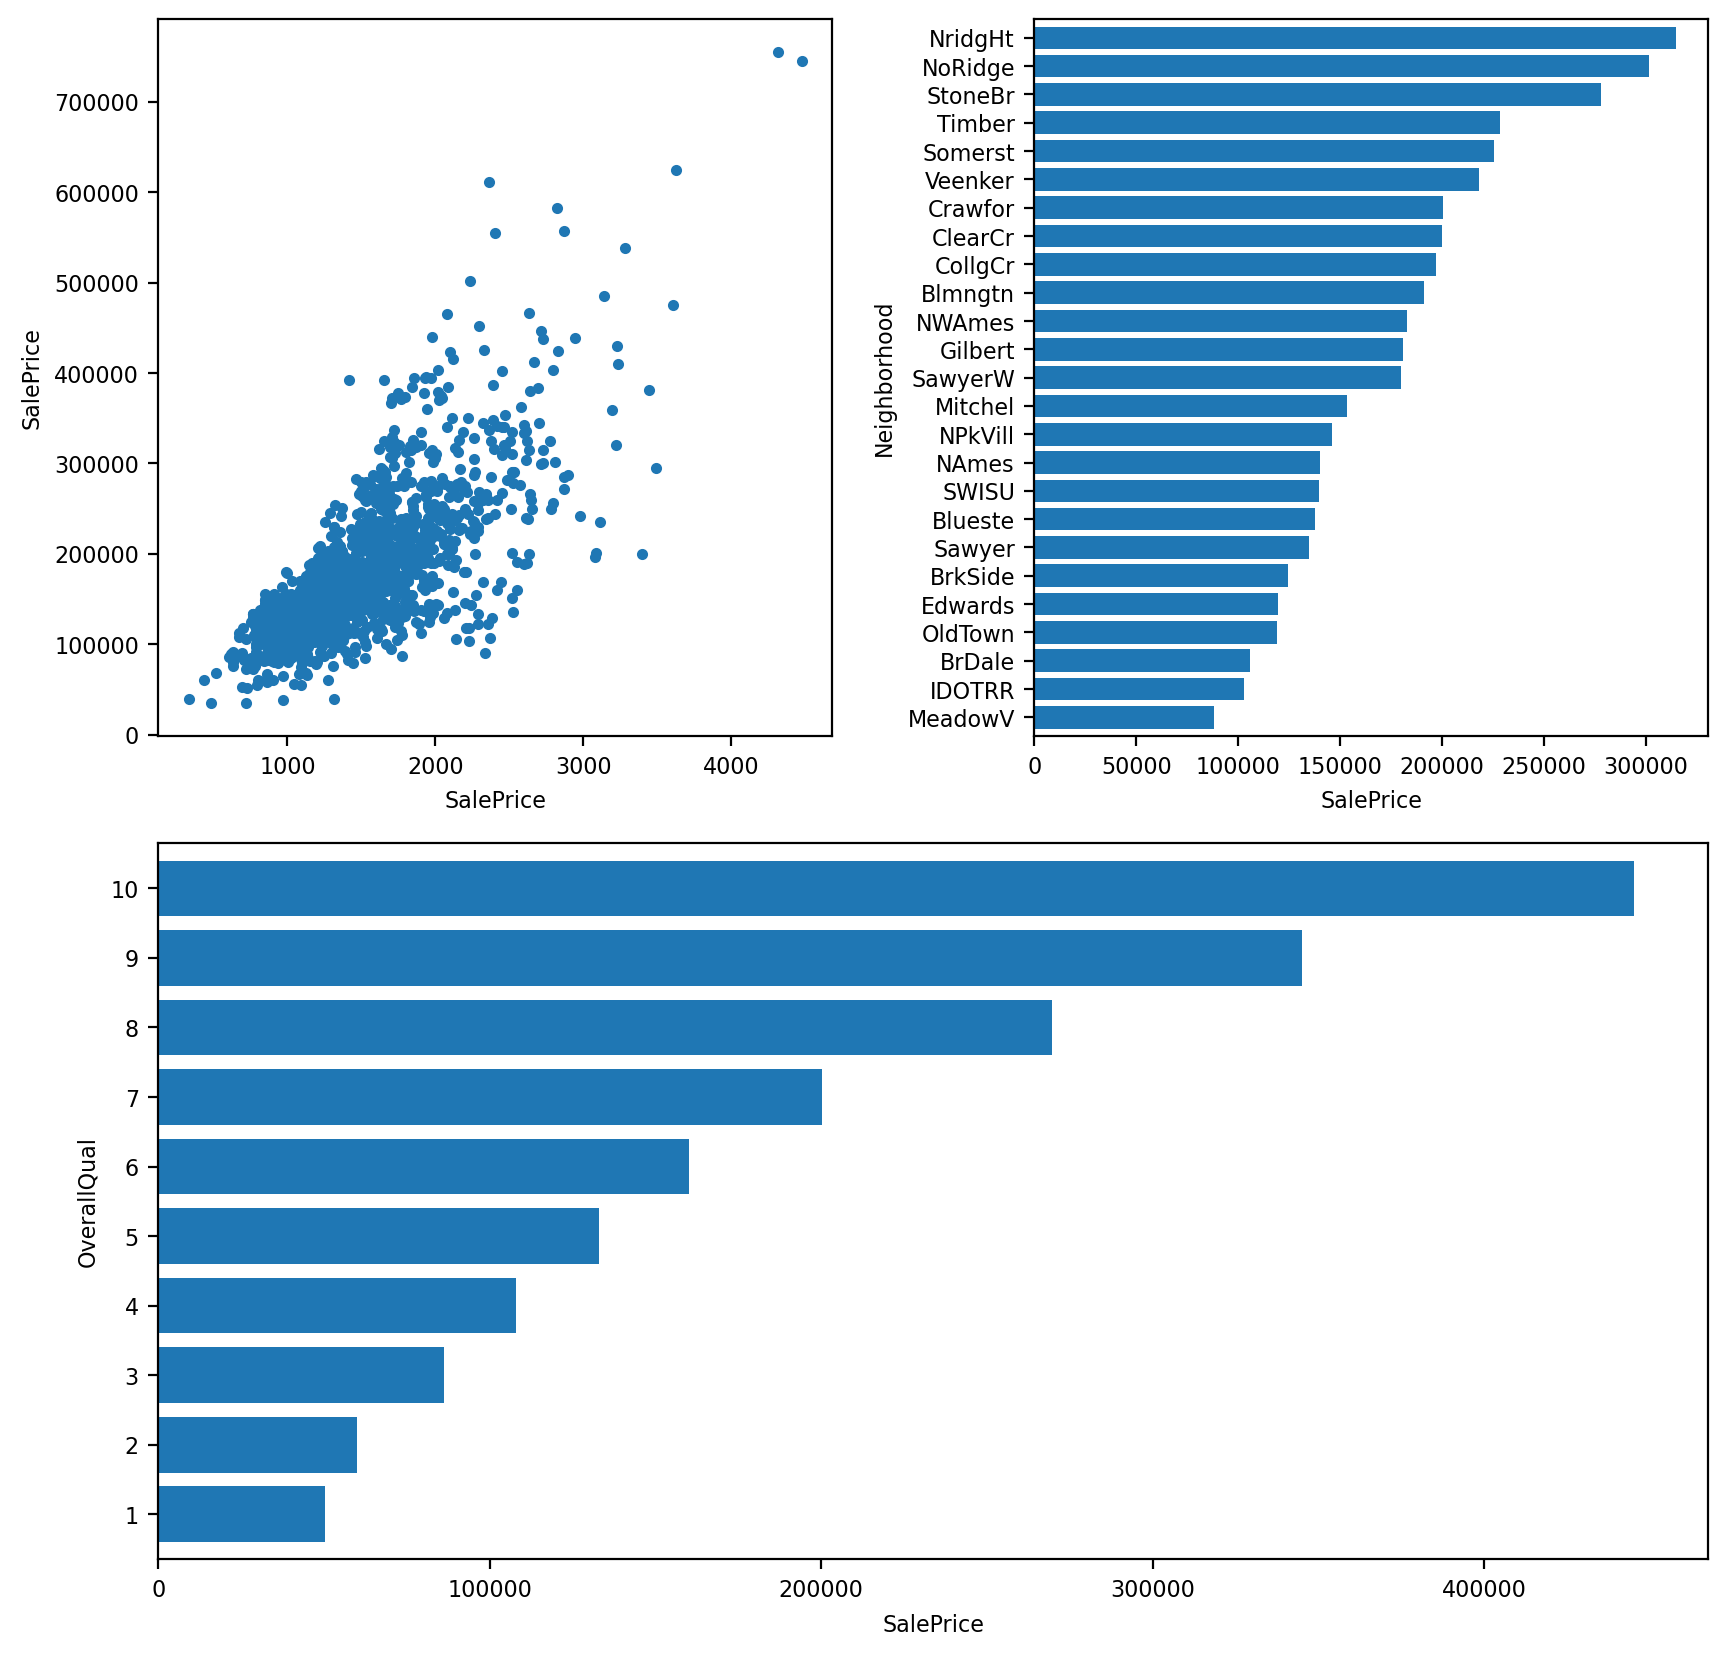

In [5]:
fig = figure(figsize=(10, 10))

gs = GridSpec(2, 2, figure=fig, wspace=0.3, hspace=0.15)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, :])

df.plot(x='GrLivArea', y='SalePrice', style='.', legend=False, ax=ax1)
df.groupby('Neighborhood')['SalePrice'].median().sort_values(ascending=True).plot.barh(width=0.8, ax=ax2)
df.groupby('OverallQual')['SalePrice'].median().sort_values(ascending=True).plot.barh(width=0.8, ax=ax3)

ax1.set_ylabel('SalePrice')
ax1.set_xlabel('SalePrice')
ax2.set_xlabel('SalePrice')
ax3.set_xlabel('SalePrice');

## Handling Missing Data

To address missing values, we replace them with appropriate default values or summaries. For example, categorical variables like ```PoolQC``` and ```Fence``` are filled with "Missing" to indicate the absence of these features, while numeric variables such as ```LotFrontage``` use the median value. This step ensures no information is lost and avoids errors during model training.

In [6]:
fill_values = {
    'PoolQC': 'Missing',
    'MiscFeature': 'Missing',
    'Alley': 'Missing',
    'Fence': 'Missing',
    'MasVnrType': 'Missing',
    'FireplaceQu': 'Missing',
    'LotFrontage': 74,
    'GarageType': 'Missing',
    'GarageYrBlt': 0,
    'GarageFinish': 'Missing',
    'GarageCars': 0,
    'GarageQual': 'Missing',
    'GarageCond': 'Missing',
    'BsmtFinType2': 'Missing',
    'BsmtExposure': 'Missing',
    'BsmtFinType1': 'Missing',
    'BsmtQual': 'Missing',
    'BsmtCond': 'Missing',
    'MasVnrArea': 0,
    'Electrical': 'SBrkr'
}

In [7]:
df = df.fillna(fill_values)

## Feature Engineering

Creating meaningful features enhances the predictive power of our model. For instance, ```TimeSinceBuild``` indicates the age of the house, and ```TotalSF``` combines basement and above-ground living area into one comprehensive metric. These derived features help the model better capture trends that may not be apparent in individual variables.

In [8]:
df['TimeSinceBuild'] = df['YrSold'] - df['YearBuilt']
df['TimeSinceRemoAdd'] = df['YrSold'] - df['YearRemodAdd']
df['TimeDiffBuildRemoAdd'] = df['YearRemodAdd'] - df['YearBuilt']

df['TotalSF'] = df['TotalBsmtSF'] + df['GrLivArea']
df['TotalBath'] = df['BsmtFullBath'] + df['BsmtHalfBath'] + df['FullBath'] + df['HalfBath']

## Separating Features

To simplify modeling, we categorize features into continuous, discrete, ordinal, and nominal types. Continuous features are numerical and can take on a wide range of values, while ordinal features have a natural order (e.g., quality ratings). Separating features allows for tailored preprocessing techniques during modeling.

In [9]:
continuous_features = [
    'LotFrontage',
    'LotArea',
    'MasVnrArea',
    'BsmtFinSF1',
    'BsmtFinSF2',
    'BsmtUnfSF',
    'TotalBsmtSF',
    '1stFlrSF',
    '2ndFlrSF',
    'LowQualFinSF',
    'GrLivArea',
    'GarageArea',
    'WoodDeckSF',
    'OpenPorchSF',
    'EnclosedPorch',
    '3SsnPorch',
    'ScreenPorch',
    'PoolArea',
    'MiscVal'
]

In [10]:
discrete_features = [
    'YearBuilt',
    'YearRemodAdd',
    'BsmtFullBath',
    'BsmtHalfBath',
    'FullBath',
    'HalfBath',
    'BedroomAbvGr',
    'KitchenAbvGr',
    'TotRmsAbvGrd',
    'Fireplaces',
    'GarageYrBlt',
    'GarageCars',
    'MoSold',
    'YrSold'
]

In [11]:
ordinal_features = [
    'OverallQual',
    'OverallCond',
    'ExterQual',
    'ExterCond',
    'BsmtQual',
    'BsmtCond',
    'BsmtExposure',
    'BsmtFinType1',
    'BsmtFinType2',
    'HeatingQC',
    'KitchenQual',
    'FireplaceQu',
    'GarageQual',
    'GarageCond'
]

In [12]:
nominal_features = [
    'MSSubClass',
    'MSZoning',
    'Street',
    'Alley',
    'LotShape',
    'LandContour',
    'Utilities',
    'LotConfig',
    'LandSlope',
    'Neighborhood',
    'Condition1',
    'Condition2',
    'BldgType',
    'HouseStyle',
    'RoofStyle',
    'RoofMatl',
    'Exterior1st',
    'Exterior2nd',
    'MasVnrType',
    'Foundation',
    'Heating',
    'CentralAir',
    'Electrical',
    'Functional',
    'GarageType',
    'GarageFinish',
    'PavedDrive',
    'PoolQC',
    'Fence',
    'MiscFeature',
    'SaleType',
    'SaleCondition'
]

In [13]:
numerical_features = continuous_features + discrete_features

categorical_features = nominal_features + ordinal_features

## Building a Predictive Model

### Model Setup

We use a histogram-based gradient boosting regressor, which is well-suited for tabular data and trains quickly. This approach leverages ensemble learning to minimize prediction error.

In [14]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_validate
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import TransformedTargetRegressor
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from hyperopt import fmin, tpe, hp, space_eval
from hyperopt import Trials, STATUS_OK
from hyperopt.pyll import scope

### Splitting Data

The dataset is split into training and testing sets to evaluate the model's performance on unseen data. A random state ensures reproducibility of results.

In [15]:
x_tr, x_te, y_tr, y_te = train_test_split(df.drop(['Id', 'SalePrice'], axis=1), df['SalePrice'], test_size=0.2, random_state=0)

### Preprocessing

Categorical variables are one-hot encoded to convert them into numerical format, while other features are left as-is. This pipeline ensures consistent preprocessing across all features.

In [16]:
categorical_transformer = Pipeline(
    steps=[
        ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ('categorical', categorical_transformer, categorical_features)
    ],
    remainder='passthrough'
)

### Hyperparameter Optimization

Using the Hyperopt library, we perform a search for the best combination of hyperparameters. This automated process reduces the need for manual tuning and can significantly improve model performance.

In [17]:
search_space = {
    'max_iter': scope.int(hp.quniform('max_iter', 10, 500, q=1)),
    'learning_rate': 10**hp.uniform('learning_rate', -3, 0),
    'max_depth': scope.int(hp.quniform('max_depth', 1, 20, q=1)),
    'max_leaf_nodes': scope.int(hp.quniform('max_leaf_nodes', 2, 200, q=1)),
    'min_samples_leaf': scope.int(hp.quniform('min_samples_leaf', 1, 200, q=1)),
    'l2_regularization': 10**hp.uniform('l2_regularization', -3, 2),
    'max_bins': scope.int(hp.quniform('max_bins', 10, 255, q=1))
}

In [18]:
def objective(params):

    regressor = HistGradientBoostingRegressor(
        **params,
        loss='squared_error',
        early_stopping='auto',
        validation_fraction=0.2,
        random_state=0
    )

    transformed_regressor = TransformedTargetRegressor(
        func=np.log,
        inverse_func=np.exp,
        regressor=regressor
    )

    pipeline = Pipeline(
        steps=[
            ('preprocessor', preprocessor),
            ('classifier', transformed_regressor)
        ]
    )

    scores = cross_validate(pipeline, x_tr, y_tr, cv=5, scoring=['neg_root_mean_squared_error'], n_jobs=-1)

    return {'model': pipeline, 'loss': -scores['test_neg_root_mean_squared_error'].mean(), 'status': STATUS_OK}

In [19]:
trials = Trials()

argmin = fmin(fn=objective, space=search_space, algo=tpe.suggest, max_evals=50, trials=trials)

100%|██████████| 50/50 [03:20<00:00,  4.01s/trial, best loss: 26110.72145846042]


After finding the best combination of parameters, we train the model on the full training set.

In [20]:
model = trials.best_trial['result']['model']

model.fit(x_tr, y_tr);

### Model Predictions

Lastly, we can explore the peformance of the model. Training output suggests the model's root mean square error is around $26,000. Let's see how it performs on the test data.

In [21]:
prediction = model.predict(x_te)

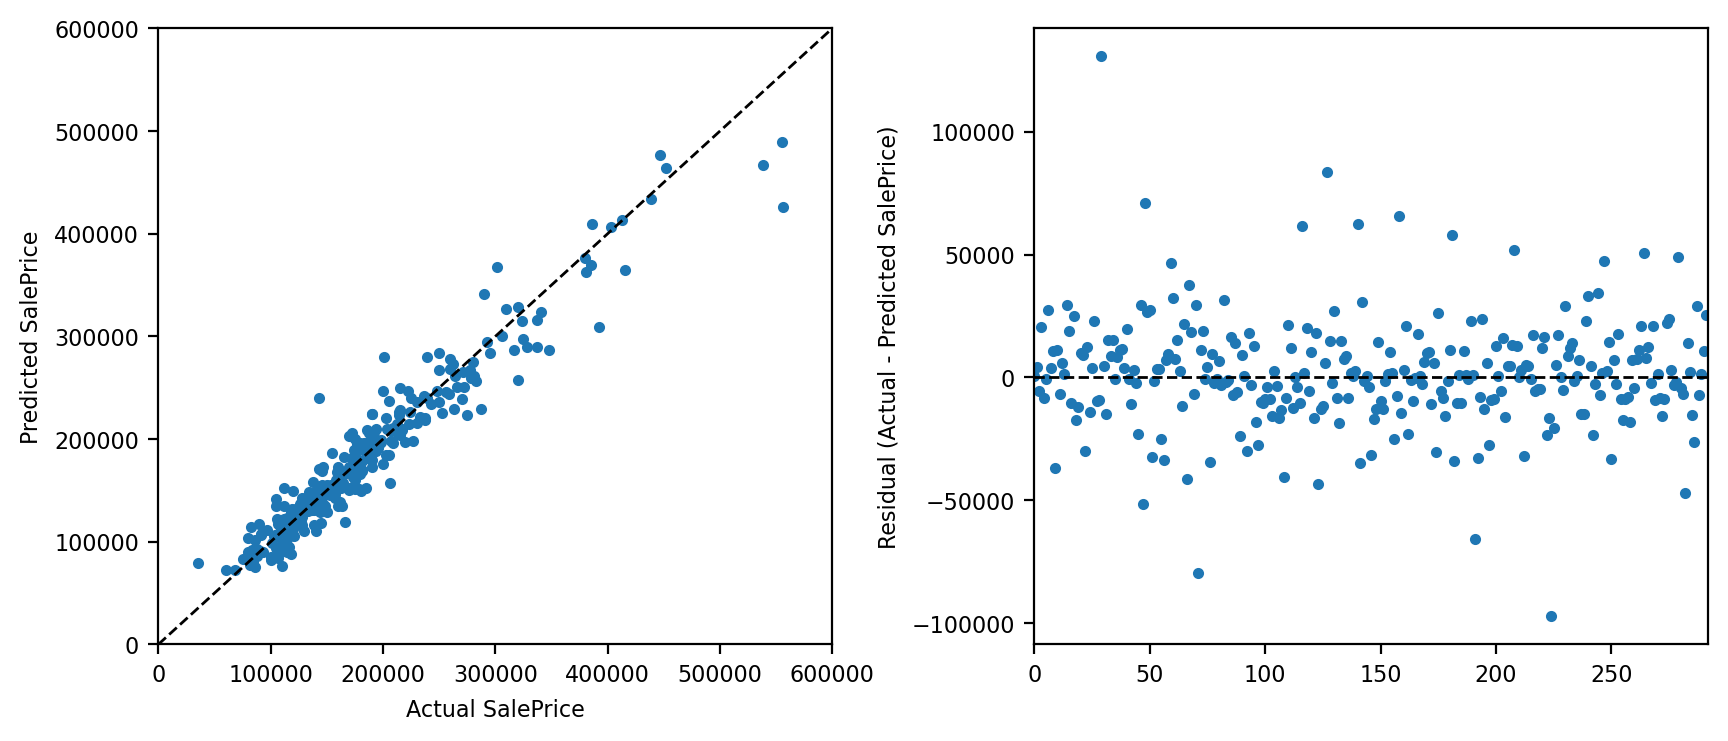

In [22]:
fig, axs = subplots(nrows=1, ncols=2, gridspec_kw={'wspace': 0.3}, figsize=(10, 4))

axs[0].plot(y_te.values, prediction, '.')
axs[0].plot([0, 600000], [0, 600000], 'k--', lw=1)
axs[0].set_ylabel('Predicted SalePrice')
axs[0].set_xlabel('Actual SalePrice')
axs[0].set_ylim(0, 600000)
axs[0].set_xlim(0, 600000)

axs[1].plot(y_te.values - prediction, '.')
axs[1].plot([0, len(y_te)], [0, 0], 'k--', lw=1)
axs[1].set_ylabel('Residual (Actual - Predicted SalePrice)')
axs[1].set_xlim(0, len(y_te));

In [23]:
print(np.sqrt(np.mean((y_te - prediction)**2)))

22679.769427367697


The model actually performs somewhat better on the test set with a root mean squared error of around $23,000. This solid performance is illustrated by plotting the predicted vs. actual ```SalePrice```, which shows a nearly linear relationship between the two. The residual plot displays a random distribution of values around zero with no evidence of heteroscedasticity.

## Conclusion

This project demonstrates the complete workflow of predicting housing prices using the Ames Housing dataset. We began by cleaning the data, handling missing values, and engineering meaningful features to enhance the model's predictive power. Exploratory data analysis provided key insights into trends and patterns, while hyperparameter optimization ensured the best model performance. Using advanced techniques like gradient boosting regression and a structured preprocessing pipeline, we achieved a robust solution for this regression problem.

Whether you're a beginner or an experienced data scientist, this case study highlights the importance of thoughtful preprocessing, careful feature engineering, and leveraging modern machine learning methods. The approach used here can be adapted to other tabular datasets, making it a versatile example for future projects.

Thank you for following along!